Saving squid.jpg to squid.jpg


/tmp/ipykernel_3876/609699101.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256])


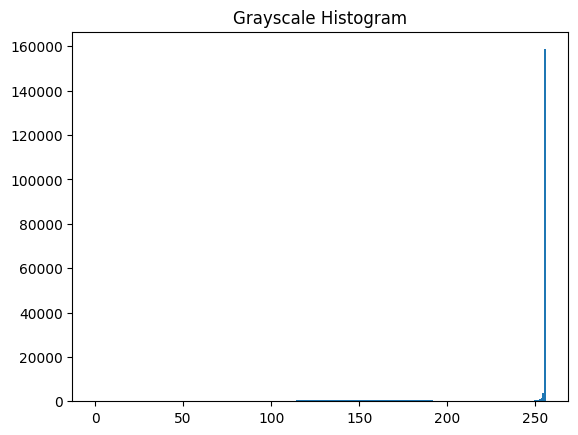

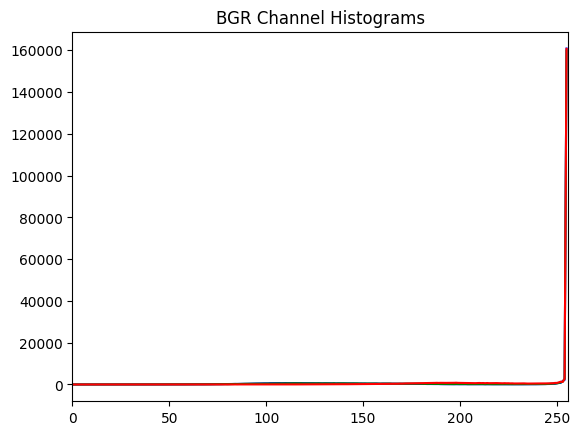

Original Image


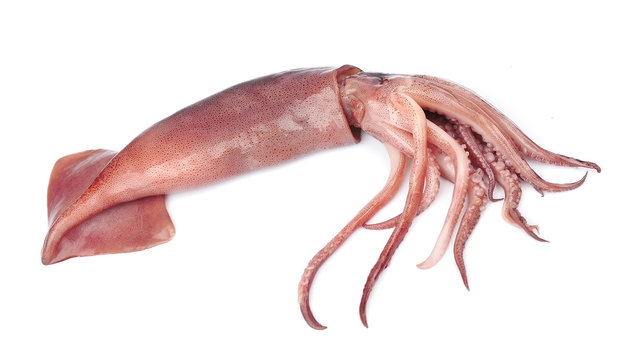

Grayscale


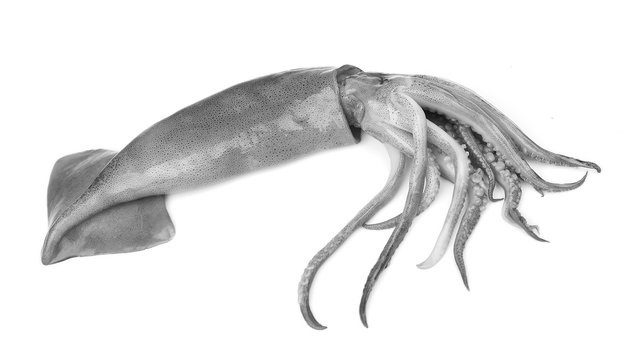

Equalized Grayscale


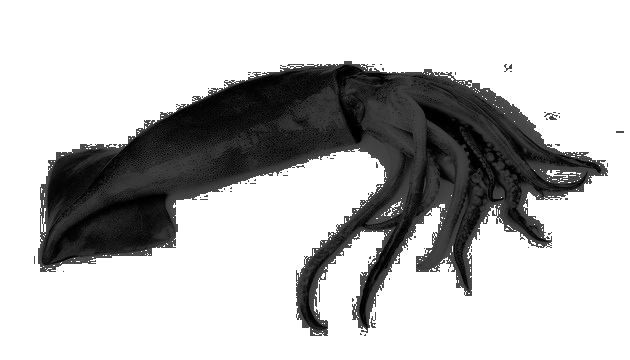

Equalized RGB (not ideal)


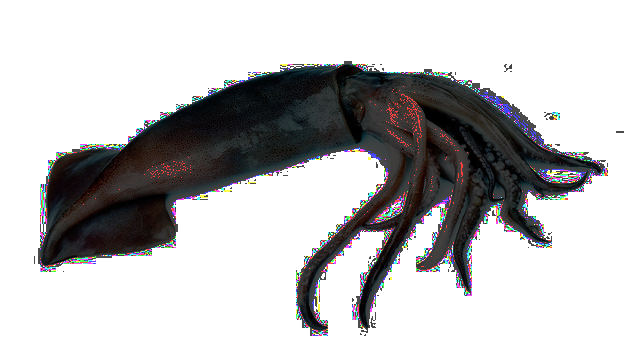

CLAHE (Best Result)


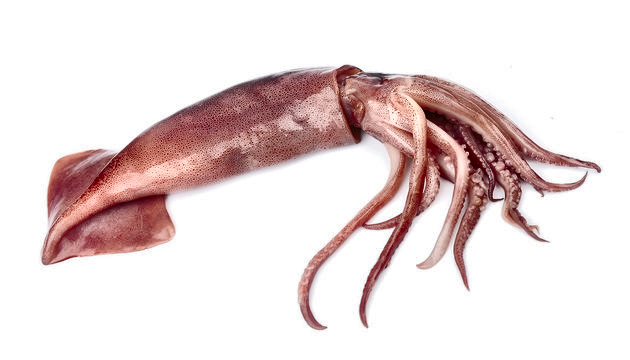

In [2]:
# Install OpenCV (if not already available)
!pip install opencv-python-headless

import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

# 1. Upload image
uploaded = files.upload()

# Get filename
image_path = list(uploaded.keys())[0]

# 2. Read image
img = cv2.imread(image_path)

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 4. Grayscale histogram
plt.figure()
plt.title("Grayscale Histogram")
plt.hist(gray.ravel(), 256, [0,256])
plt.show()

# 5. BGR histograms
colors = ('b','g','r')
plt.figure()
for i, col in enumerate(colors):
    hist = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(hist, color=col)
plt.title("BGR Channel Histograms")
plt.xlim([0,256])
plt.show()

# 6. Histogram Equalization (Grayscale)
eq_gray = cv2.equalizeHist(gray)

# 7. Histogram Equalization (RGB channels)
b, g, r = cv2.split(img)
eq_b = cv2.equalizeHist(b)
eq_g = cv2.equalizeHist(g)
eq_r = cv2.equalizeHist(r)
eq_color = cv2.merge((eq_b, eq_g, eq_r))

# 8. CLAHE (better method)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(l)

limg = cv2.merge((cl,a,b))
clahe_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

# 9. Display results
print("Original Image")
cv2_imshow(img)

print("Grayscale")
cv2_imshow(gray)

print("Equalized Grayscale")
cv2_imshow(eq_gray)

print("Equalized RGB (not ideal)")
cv2_imshow(eq_color)

print("CLAHE (Best Result)")
cv2_imshow(clahe_img)